# Notebook 2: Data Exploration (EDA)

**Goal:** Load the CIFAR-10 dataset and thoroughly understand it before building any models.

**Why EDA Matters:**
- You can't build a good model without understanding your data
- We need to check: How many images? What size? Are classes balanced? What do they look like?
- The insights from EDA inform our preprocessing and model choices

---

## 2.1 Setup and Imports

In [1]:
# Add the project root to Python's path so we can import our src/ modules
import sys
sys.path.insert(0, '..')

# Standard data science imports
import numpy as np                  # Numerical computing (arrays, math)
import matplotlib.pyplot as plt     # Plotting library
import seaborn as sns               # Statistical visualization (built on matplotlib)

# Our custom modules from src/
from src.data_utils import get_raw_cifar10, CIFAR10_CLASSES, CIFAR10_MEAN, CIFAR10_STD
from src.visualize import plot_sample_grid, plot_class_distribution, plot_pixel_histograms

# Make plots appear inline in the notebook and set a clean style
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')  # Clean, professional-looking plots

print("All imports successful!")

All imports successful!


## 2.2 Load the Dataset

CIFAR-10 is built into PyTorch's `torchvision` library. When we call `download=True`, it automatically downloads the dataset (~170MB) if it's not already on disk.

The dataset is split into:
- **Training set** (50,000 images): Used to teach the model
- **Test set** (10,000 images): Used to evaluate the model on data it has never seen

In [2]:
# Load CIFAR-10 without any transforms (raw images)
# get_raw_cifar10() is our helper from src/data_utils.py
# It calls torchvision.datasets.CIFAR10 with download=True and transform=None
train_dataset, test_dataset = get_raw_cifar10(data_dir='../data')

# Let's inspect the basic properties of the dataset
print("=" * 50)
print("CIFAR-10 Dataset Overview")
print("=" * 50)
print(f"Training set size:  {len(train_dataset):,} images")
print(f"Test set size:      {len(test_dataset):,} images")
print(f"Total images:       {len(train_dataset) + len(test_dataset):,}")
print(f"Number of classes:  {len(CIFAR10_CLASSES)}")
print(f"Class names:        {CIFAR10_CLASSES}")

# Access the raw data array
# train_dataset.data is a numpy array of ALL training images
print(f"\nData array shape:   {train_dataset.data.shape}")
print(f"  → {train_dataset.data.shape[0]} images")
print(f"  → {train_dataset.data.shape[1]}x{train_dataset.data.shape[2]} pixels")
print(f"  → {train_dataset.data.shape[3]} color channels (R, G, B)")
print(f"\nPixel value range:  {train_dataset.data.min()} to {train_dataset.data.max()}")
print(f"Data type:          {train_dataset.data.dtype}")
print(f"Memory usage:       {train_dataset.data.nbytes / 1e6:.1f} MB")

CIFAR-10 Dataset Overview
Training set size:  50,000 images
Test set size:      10,000 images
Total images:       60,000
Number of classes:  10
Class names:        ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

Data array shape:   (50000, 32, 32, 3)
  → 50000 images
  → 32x32 pixels
  → 3 color channels (R, G, B)

Pixel value range:  0 to 255
Data type:          uint8
Memory usage:       153.6 MB


### Understanding the Output:
- **Shape (50000, 32, 32, 3):** 50,000 images, each 32 pixels tall, 32 pixels wide, 3 color channels
- **Pixel values 0-255:** Standard 8-bit color range. 0 = black, 255 = brightest
- **dtype uint8:** Unsigned 8-bit integer (0-255), the most memory-efficient format for images
- **~150MB:** Small enough to fit entirely in RAM on any modern computer

## 2.3 Visualize Sample Images

Let's see what the images actually look like. We'll display 5 random samples from each class.

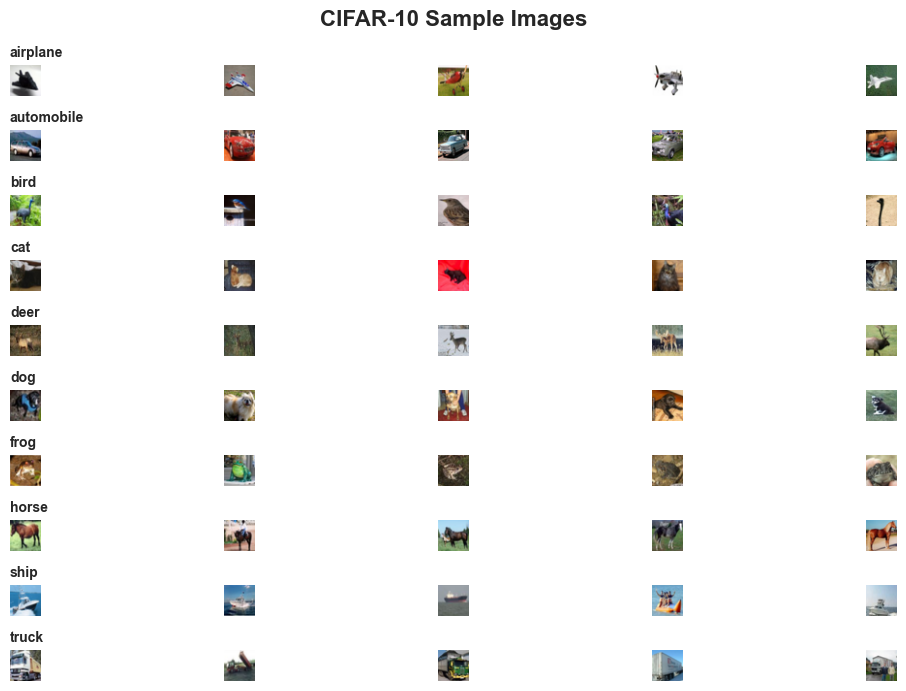

Key observations:
- Images are VERY small (32x32) — hard even for humans at this resolution
- There's huge variation within each class (different angles, colors, backgrounds)
- Some classes look similar: cat/dog, automobile/truck, deer/horse


In [3]:
# Display a grid of sample images using our helper function
# plot_sample_grid picks n_per_class images for each of the 10 classes
fig = plot_sample_grid(train_dataset, CIFAR10_CLASSES, n_per_class=5)
plt.show()

print("Key observations:")
print("- Images are VERY small (32x32) — hard even for humans at this resolution")
print("- There's huge variation within each class (different angles, colors, backgrounds)")
print("- Some classes look similar: cat/dog, automobile/truck, deer/horse")

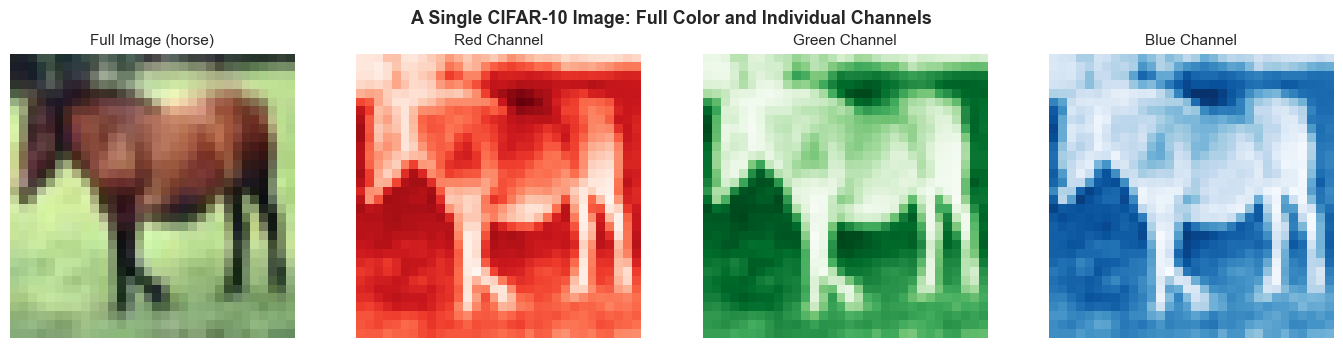


This horse image is just 32x32 = 1,024 pixels.
With 3 color channels, that's 3,072 total values the model sees.
Compare to a smartphone photo: ~4000x3000 = 12 MILLION pixels!


In [4]:
# Let's zoom into a single image to see individual pixels
# This shows just how little information the model has to work with

single_img = train_dataset.data[7]  # Pick image at index 7
label = train_dataset.targets[7]

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))

# Original image
axes[0].imshow(single_img)
axes[0].set_title(f'Full Image ({CIFAR10_CLASSES[label]})', fontsize=11)
axes[0].axis('off')

# Individual color channels
channel_names = ['Red Channel', 'Green Channel', 'Blue Channel']
cmaps = ['Reds', 'Greens', 'Blues']
for i in range(3):
    axes[i+1].imshow(single_img[:, :, i], cmap=cmaps[i])
    axes[i+1].set_title(channel_names[i], fontsize=11)
    axes[i+1].axis('off')

plt.suptitle('A Single CIFAR-10 Image: Full Color and Individual Channels',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nThis {CIFAR10_CLASSES[label]} image is just 32x32 = 1,024 pixels.")
print(f"With 3 color channels, that's {32*32*3:,} total values the model sees.")
print(f"Compare to a smartphone photo: ~4000x3000 = 12 MILLION pixels!")

## 2.4 Class Distribution

An important check: are the classes **balanced** (equal number of images per class)?

If classes are imbalanced (e.g., 90% cats, 10% dogs), the model might learn to always predict "cat" and still get 90% accuracy! Balanced datasets avoid this problem.

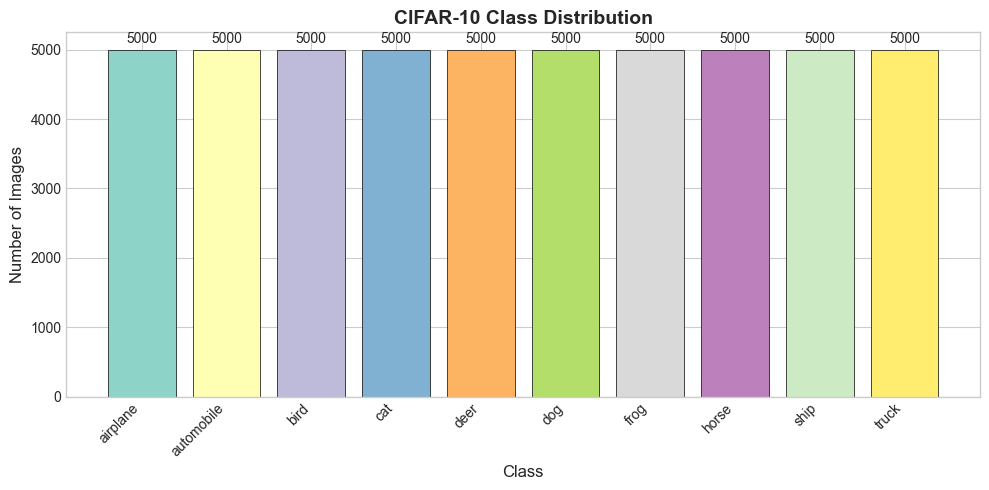


CIFAR-10 is perfectly balanced: exactly 5,000 images per class.
This is ideal for training — the model sees equal examples of each class.

Note: Real-world datasets are RARELY this balanced!
In practice, you'd need techniques like oversampling or class weighting.


In [5]:
# Plot class distribution for training set
fig = plot_class_distribution(train_dataset, CIFAR10_CLASSES)
plt.show()

print("\nCIFAR-10 is perfectly balanced: exactly 5,000 images per class.")
print("This is ideal for training — the model sees equal examples of each class.")
print("\nNote: Real-world datasets are RARELY this balanced!")
print("In practice, you'd need techniques like oversampling or class weighting.")

In [6]:
# Also check the test set distribution
from collections import Counter

test_counts = Counter(test_dataset.targets)
print("Test set class distribution:")
for i, name in enumerate(CIFAR10_CLASSES):
    print(f"  {name:12s}: {test_counts[i]:,} images")

print(f"\nTest set is also balanced: {test_counts[0]:,} images per class.")

Test set class distribution:
  airplane    : 1,000 images
  automobile  : 1,000 images
  bird        : 1,000 images
  cat         : 1,000 images
  deer        : 1,000 images
  dog         : 1,000 images
  frog        : 1,000 images
  horse       : 1,000 images
  ship        : 1,000 images
  truck       : 1,000 images

Test set is also balanced: 1,000 images per class.


## 2.5 Pixel Statistics

Understanding the distribution of pixel values helps us decide how to **normalize** the data.

**Why normalize?**
- Raw pixel values range from 0 to 255
- Neural networks train much better when inputs are centered around 0 with small values
- We'll compute the mean and standard deviation per color channel, then use them to normalize:
  `normalized_pixel = (pixel - mean) / std`

In [7]:
# Compute per-channel statistics on the TRAINING set
# (We compute stats on training data only, then apply them to test data too)

# train_dataset.data shape: (50000, 32, 32, 3)
data = train_dataset.data.astype(np.float32)  # Convert to float for calculations

# Compute mean and std across all pixels and all images, per channel
# axis=(0,1,2) means: average over images(0), height(1), width(2), keep channels(3)
channel_means = data.mean(axis=(0, 1, 2)) / 255.0  # Scale to [0,1]
channel_stds = data.std(axis=(0, 1, 2)) / 255.0

print("Per-Channel Statistics (scaled to [0, 1]):")
print(f"{'Channel':<8} {'Mean':>8} {'Std':>8}")
print("-" * 26)
for i, color in enumerate(['Red', 'Green', 'Blue']):
    print(f"{color:<8} {channel_means[i]:>8.4f} {channel_stds[i]:>8.4f}")

print(f"\nThese are the values we'll use for normalization:")
print(f"  CIFAR10_MEAN = ({channel_means[0]:.4f}, {channel_means[1]:.4f}, {channel_means[2]:.4f})")
print(f"  CIFAR10_STD  = ({channel_stds[0]:.4f}, {channel_stds[1]:.4f}, {channel_stds[2]:.4f})")
print(f"\n(Already stored in src/data_utils.py as constants!)")

Per-Channel Statistics (scaled to [0, 1]):
Channel      Mean      Std
--------------------------
Red        0.4914   0.2470
Green      0.4822   0.2435
Blue       0.4465   0.2616

These are the values we'll use for normalization:
  CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
  CIFAR10_STD  = (0.2470, 0.2435, 0.2616)

(Already stored in src/data_utils.py as constants!)


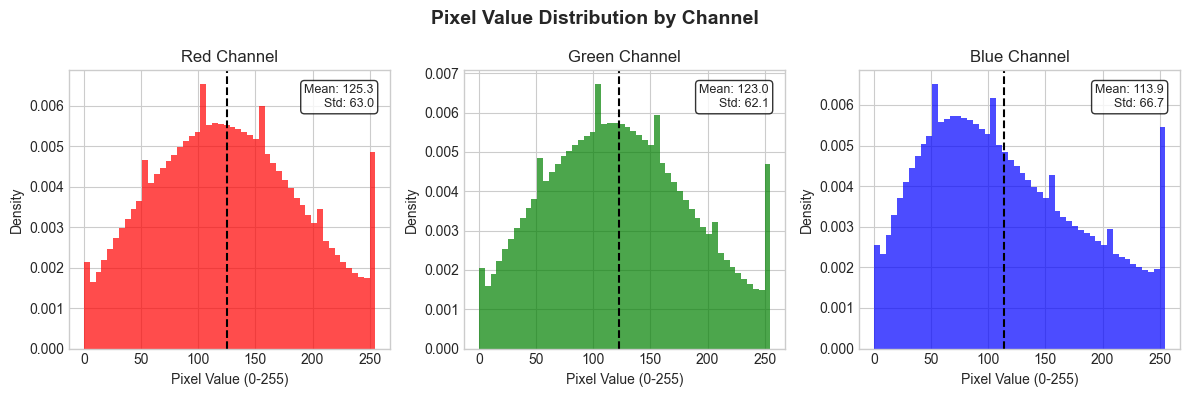

Observations:
- All channels have similar distributions (this is typical for natural images)
- The Red channel has a slightly higher mean (warmer tones in the dataset)
- Values span the full 0-255 range with no obvious gaps
- The distributions are roughly bell-shaped, which is good for normalization


In [8]:
# Visualize pixel value distributions per channel
fig = plot_pixel_histograms(train_dataset)
plt.show()

print("Observations:")
print("- All channels have similar distributions (this is typical for natural images)")
print("- The Red channel has a slightly higher mean (warmer tones in the dataset)")
print("- Values span the full 0-255 range with no obvious gaps")
print("- The distributions are roughly bell-shaped, which is good for normalization")

## 2.6 Summary and Key Observations

### What we learned about CIFAR-10:

1. **Small images (32x32):** Only 1,024 pixels per channel. This is very low resolution — even humans struggle to identify some of these images.

2. **Balanced classes:** Exactly 5,000 training images and 1,000 test images per class. No need for special handling of class imbalance.

3. **High intra-class variation:** Images within the same class look very different (different angles, backgrounds, lighting, colors). The model must learn general patterns, not memorize specific images.

4. **Confusable classes:** Some class pairs are visually similar:
   - cat ↔ dog (both small furry animals)
   - automobile ↔ truck (both vehicles on roads)
   - deer ↔ horse (both large four-legged animals)

5. **Normalization values:** Mean ≈ (0.49, 0.48, 0.45), Std ≈ (0.25, 0.24, 0.26). We'll use these to normalize pixel values to have zero mean and unit variance.

### Next Steps:
In the next notebook, we'll try to classify these images using **traditional ML** (no deep learning yet) to establish a baseline.